# Unit 4, Lecture 1: Constrained Particle Motion

**Course**: Dynamic Systems Modeling (702MH0C023) 
**Unit**: 4 - Particle Kinetics 
**Duration**: 90 minutes (60 min teaching + 30 min practice) 
**Prerequisites**: Unit 1 (Kinematics), Unit 2 (Newton's Laws, Lagrangian)

---

## Learning Objectives

By the end of this lecture, you will be able to:

1. **Define** constraints and classify them (holonomic vs non-holonomic)
2. **Calculate** degrees of freedom for constrained particle systems
3. **Apply** Newton's laws to particles with constraint forces
4. **Derive** equations of motion for single and multiple constrained particles
5. **Analyze** systems with springs, cables, and contact constraints
6. **Implement** Python simulations of constrained particle dynamics

---

## Connection to Previous Lectures

### What We've Learned:
- **Unit 1**: Kinematics - describing motion (position, velocity, acceleration)
- **Unit 2**: Newton's Laws - forces cause acceleration (ΣF = ma)
- **Unit 2**: Lagrangian Mechanics - energy-based approach to dynamics

### Today's Focus:
**How do constraints affect particle motion?**

In real systems, particles aren't free to move anywhere:
- Beads slide on wires (1D constraint)
- Objects slide on surfaces (2D constraint)
- Cables restrict motion (tension forces)
- Contact prevents penetration (normal forces)

Today we learn how to **find the motion AND the constraint forces** simultaneously.

---

## Why This Matters

### Engineering Applications:
- **Elevators**: Cables constrain motion, tension must support weight
- **Ski lifts**: Chair hangs from cable, constrained path
- **Roller coasters**: Track constrains car, normal force varies
- **Spacecraft tethers**: Connected satellites, tension dynamics
- **Manufacturing**: Parts on conveyors, guided motion

### The Challenge:
When a particle is constrained:
1. **Unknown forces** appear (tension, normal force, friction)
2. Motion is **restricted** (fewer degrees of freedom)
3. **Constraint equations** must be satisfied

We need methods to solve for both motion AND constraint forces!

## Part 1: What is a Constraint?

### Definition
A **constraint** is a restriction on the motion of a system that **reduces the degrees of freedom**.

### Mathematical Form
A constraint equation relates the coordinates:

$$f(x, y, z, t) = 0$$

**Examples**:
- Bead on wire: $y = 0, z = 0$ (moves only along x-axis)
- Particle on sphere: $x^2 + y^2 + z^2 = R^2$ (surface constraint)
- Cable length: $\sqrt{x_1^2 + y_1^2} + \sqrt{x_2^2 + y_2^2} = L$ (pulley system)

---

### Types of Constraints

#### 1. **Holonomic Constraints**
Can be expressed as equations involving only coordinates and time:

$$f(q_1, q_2, \ldots, q_n, t) = 0$$

**Examples**:
- Particle on circle: $x^2 + y^2 = R^2$
- Rigid body: $|r_A - r_B| = L$ (fixed distance)
- Cable length: $\sum_i |r_i - r_{i+1}| = L_{total}$

#### 2. **Non-Holonomic Constraints**
Cannot be integrated to get equation in coordinates only (involve velocities):

$$g(\dot{q}_1, \dot{q}_2, \ldots, \dot{q}_n, t) = 0$$

**Examples**:
- Rolling without slipping: $v = \omega R$ (velocity constraint)
- Ice skating: $v_{\perp} = 0$ (no sideways velocity)
- Knife edge: velocity perpendicular to blade is zero

**Note**: We focus on holonomic constraints today. Non-holonomic constraints appear in Unit 5 (Rigid Bodies).

---

### Degrees of Freedom

**Unconstrained particle in 3D**: 3 DOF (x, y, z)

**With k constraints**: DOF = 3 - k

**Examples**:
- Bead on straight wire: 2 constraints → 1 DOF
- Particle on surface: 1 constraint → 2 DOF
- Two particles with fixed distance: 3×2 - 1 = 5 DOF

---

### Constraint Forces

When motion is constrained, **constraint forces** appear:

| Constraint Type | Force Name | Direction | Magnitude |
|----------------|------------|-----------|-----------|
| Surface contact | Normal force N | Perpendicular to surface | Unknown (≥ 0) |
| Cable/rope | Tension T | Along cable | Unknown (≥ 0) |
| Rod (rigid) | Compression/Tension | Along rod | Unknown (any sign) |
| Frictionless surface | Normal only | Perpendicular | Unknown (≥ 0) |

**Key Point**: Constraint forces do **zero virtual work** (perpendicular to allowed motion).

This is why Lagrangian mechanics (Unit 2) is powerful - it eliminates constraint forces automatically!

![Free Body Diagram — Particle on Frictionless Incline](figs/U4_L1_incline_fbd.png)

*Free Body Diagram — Particle on Frictionless Incline*


## Deep Dive: Why Do Constraint Forces Do No Work?

This is a profound insight that connects Newton's and Lagrange's approaches!

### The Argument:

1. **Constraint forces are perpendicular to allowed motion**
 - Normal force ⊥ to surface → particle slides ON surface, not INTO it
 - Tension along rope → particle can't move along rope direction (inextensible)

2. **Work = Force · Displacement**
 $$W = \vec{F} \cdot \Delta \vec{r} = |\vec{F}| \cdot |\Delta \vec{r}| \cdot \cos\theta$$
 
 If $\theta = 90°$, then $\cos(90°) = 0$ → **W = 0**

3. **Virtual Work Principle**
 For any **infinitesimal displacement δr that respects constraints**:
 $$\delta W_{constraint} = \vec{F}_{constraint} \cdot \delta \vec{r} = 0$$

### Example: Bead on Wire

<img src="https://via.placeholder.com/400x200.png?text=Bead+on+Wire" width="400"/>

- Bead constrained to x-axis (wire along x)
- Normal force N acts in y-direction
- Motion δr = (δx, 0, 0)
- Virtual work: $\delta W = N \cdot \delta r_y = N \cdot 0 = 0$ 

### Why This Matters:

In **Lagrangian mechanics**, we use generalized coordinates that automatically satisfy constraints. The constraint forces disappear from the equations!

$$\frac{d}{dt}\left(\frac{\partial L}{\partial \dot{q}}\right) - \frac{\partial L}{\partial q} = Q_{applied}$$

Only applied forces (gravity, springs, etc.) appear - not constraint forces!

**Today**: We use Newton's laws directly → we MUST include constraint forces → more equations, but we find all forces explicitly.

## Part 2: Newton's Laws with Constraints

### The Standard Approach

For a particle with constraints:

**Step 1: Draw Free Body Diagram (FBD)**
- Show ALL forces (applied + constraint)
- Choose coordinate system

**Step 2: Write Newton's Second Law**
$$\sum \vec{F} = m\vec{a}$$

In component form:
$$\sum F_x = m a_x$$
$$\sum F_y = m a_y$$
$$\sum F_z = m a_z$$

**Step 3: Write Constraint Equations**
$$f(x, y, z) = 0$$

Differentiate twice to get acceleration constraint:
$$\frac{d^2 f}{dt^2} = 0$$

**Step 4: Solve System of Equations**
- Number of unknowns = accelerations + constraint forces
- Number of equations = Newton's laws + constraint acceleration equations
- System should be solvable!

---

### Example 1: Particle on Frictionless Incline

**Given**:
- Mass m on incline (angle θ)
- No friction
- Gravity g downward

**Find**: Acceleration down incline, normal force N

#### Step 1: Free Body Diagram

```
 N (perpendicular to surface)
 ↑
 |
 |_______ m
 ↓
 mg (downward)
```

Coordinate system: x along incline (positive down), y perpendicular to incline

#### Step 2: Resolve Forces

**Gravity components**:
- Along incline: $mg \sin\theta$
- Perpendicular: $-mg \cos\theta$ (into surface)

**Newton's Laws**:
$$x: \quad mg\sin\theta = m a_x$$
$$y: \quad N - mg\cos\theta = m a_y$$

#### Step 3: Constraint

Particle stays on incline surface:
$$a_y = 0 \quad \text{(no acceleration perpendicular to surface)}$$

#### Step 4: Solve

From x-equation:
$$a_x = g\sin\theta$$

From y-equation with $a_y = 0$:
$$N = mg\cos\theta$$

**Result**:
- **Acceleration**: $a = g\sin\theta$ down the incline
- **Normal force**: $N = mg\cos\theta$

**Checks**:
- At θ=0° (horizontal): a=0, N=mg 
- At θ=90° (vertical): a=g, N=0 

### Simulation: Particle on Incline

Let's visualize this motion and verify our results!

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)


 Libraries imported successfully!
NumPy version: 2.3.5
Matplotlib version: 3.10.7


In [2]:
# Simulate particle sliding down incline
def simulate_incline(m=1.0, theta_deg=30, g=9.81, t_max=3.0):
    """
    Simulate particle on frictionless incline

    Parameters:
    - m: mass (kg)
    - theta_deg: incline angle (degrees)
    - g: gravity (m/s²)
    - t_max: simulation time (s)

    Returns:
    - t, x, v, a, N: arrays of time, position, velocity, acceleration, normal force
    """
    theta = np.radians(theta_deg)

    # Theoretical acceleration and normal force
    a_theory = g * np.sin(theta)
    N_theory = m * g * np.cos(theta)

    # Time array
    t = np.linspace(0, t_max, 300)

    # Kinematics (constant acceleration)
    x = 0.5 * a_theory * t**2  # Position along incline
    v = a_theory * t  # Velocity
    a = np.full_like(t, a_theory)  # Acceleration (constant)
    N = np.full_like(t, N_theory)  # Normal force (constant)

    return t, x, v, a, N, theta


# Test with 30° incline
m, theta_deg, g = 1.0, 30, 9.81
t, x, v, a, N, theta = simulate_incline(m, theta_deg, g, t_max=3.0)

print(f"Particle on {theta_deg}° Incline")
print(f"=" * 40)
print(f"Mass: {m} kg")
print(f"Gravity: {g} m/s²")
print(f"Angle: {theta_deg}° ({theta:.3f} rad)")
print(f"\nTheoretical Results:")
print(f"Acceleration: {a[0]:.3f} m/s²")
print(f"Normal Force: {N[0]:.3f} N")
print(f"\nAfter {t[-1]:.1f} seconds:")
print(f"Distance traveled: {x[-1]:.2f} m")
print(f"Final velocity: {v[-1]:.2f} m/s")


Particle on 30° Incline
Mass: 1.0 kg
Gravity: 9.81 m/s²
Angle: 30° (0.524 rad)

Theoretical Results:
 Acceleration: 4.905 m/s²
 Normal Force: 8.496 N

After 3.0 seconds:
 Distance traveled: 22.07 m
 Final velocity: 14.71 m/s


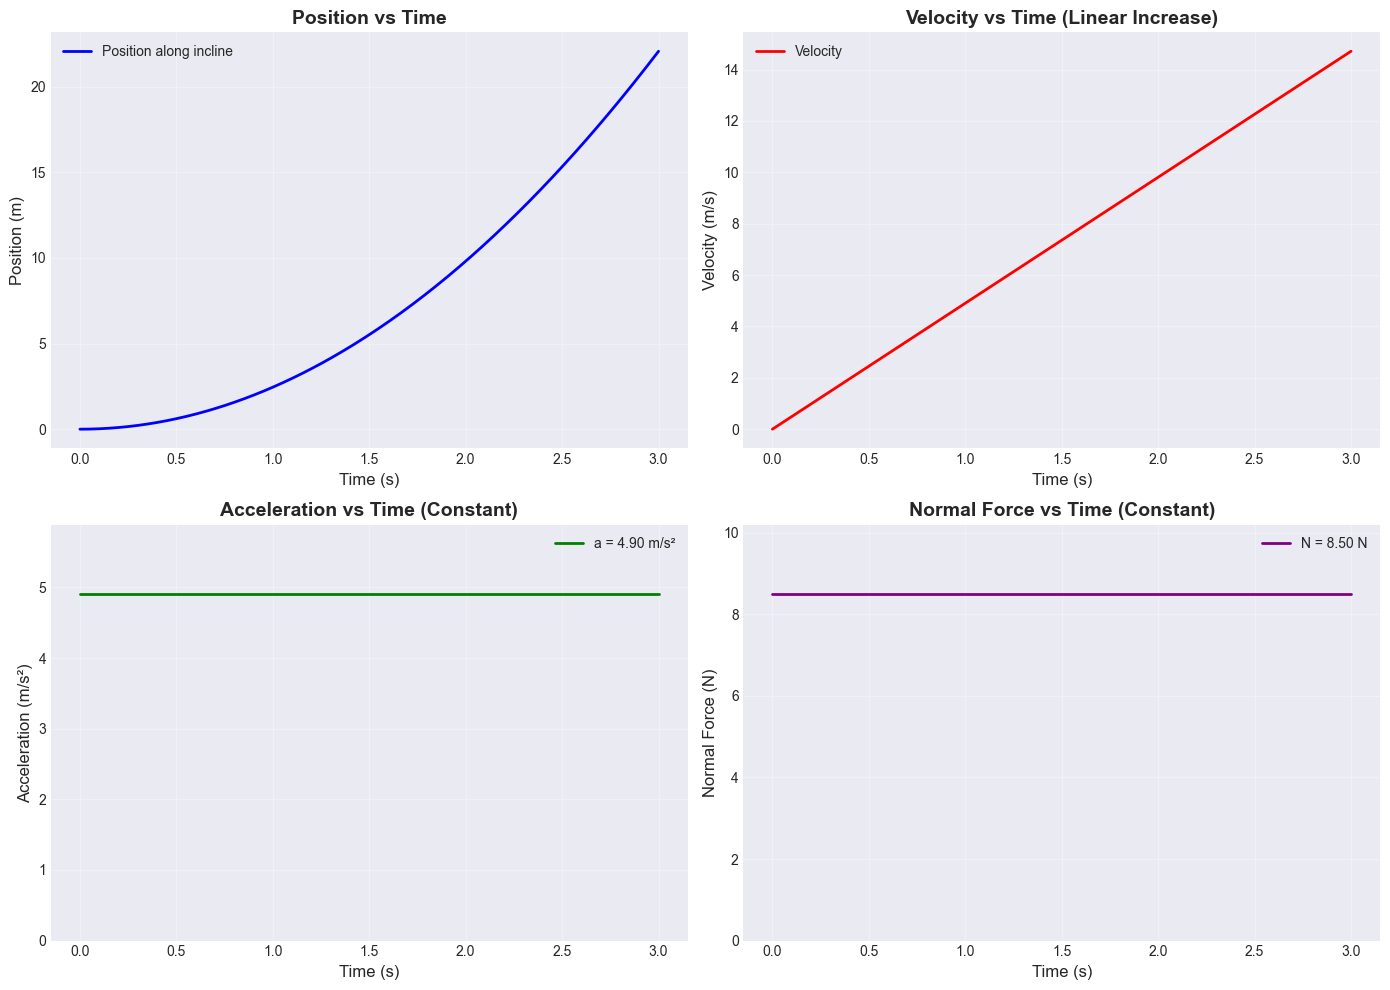


 Verification: a = g·sin(θ) = 9.81·sin(30°) = 4.905 m/s²
 Verification: N = mg·cos(θ) = 1.0·9.81·cos(30°) = 8.496 N


In [3]:
# Visualize motion on incline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Position vs Time
axes[0, 0].plot(t, x, 'b-', linewidth=2, label='Position along incline')
axes[0, 0].set_xlabel('Time (s)', fontsize=12)
axes[0, 0].set_ylabel('Position (m)', fontsize=12)
axes[0, 0].set_title('Position vs Time', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Velocity vs Time
axes[0, 1].plot(t, v, 'r-', linewidth=2, label='Velocity')
axes[0, 1].set_xlabel('Time (s)', fontsize=12)
axes[0, 1].set_ylabel('Velocity (m/s)', fontsize=12)
axes[0, 1].set_title('Velocity vs Time (Linear Increase)',
                     fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Acceleration vs Time (constant)
axes[1, 0].plot(t, a, 'g-', linewidth=2, label=f'a = {a[0]:.2f} m/s²')
axes[1, 0].set_xlabel('Time (s)', fontsize=12)
axes[1, 0].set_ylabel('Acceleration (m/s²)', fontsize=12)
axes[1, 0].set_title('Acceleration vs Time (Constant)',
                     fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_ylim([0, a[0]*1.2])

# Normal Force vs Time (constant)
axes[1, 1].plot(t, N, 'purple', linewidth=2, label=f'N = {N[0]:.2f} N')
axes[1, 1].set_xlabel('Time (s)', fontsize=12)
axes[1, 1].set_ylabel('Normal Force (N)', fontsize=12)
axes[1, 1].set_title('Normal Force vs Time (Constant)',
                     fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_ylim([0, N[0]*1.2])

plt.tight_layout()
plt.show()

print(
    f"\n Verification: a = g·sin(θ) = {g}·sin({theta_deg}°) = {
        a[0]:.3f} m/s²")
print(
    f" Verification: N = mg·cos(θ) = {m}·{g}·cos({theta_deg}°) = {
        N[0]:.3f} N")


In [4]:
# Create animation of particle sliding down incline
fig, ax = plt.subplots(figsize=(10, 6))

# Draw incline
incline_length = x[-1] + 2
incline_x = np.array([0, incline_length * np.cos(theta)])
incline_y = np.array([0, -incline_length * np.sin(theta)])
ax.plot(incline_x, incline_y, 'k-', linewidth=3, label='Incline')

# Draw ground
ground_x = np.linspace(-1, incline_x[-1] + 1, 100)
ground_y = np.zeros_like(ground_x)
ax.plot(ground_x, ground_y, 'brown', linewidth=2)

# Particle
particle, = ax.plot([], [], 'ro', markersize=20, label='Particle (m=1kg)')

# Info text
info_text = ax.text(
    0.02,
    0.95,
    '',
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.8))

ax.set_xlim(-1, incline_x[-1] + 1)
ax.set_ylim(-incline_y[-1] - 2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title(
    f'Particle Sliding Down {theta_deg}° Incline (Animation)',
    fontsize=14,
    fontweight='bold')
ax.legend(loc='upper right')


def animate(frame):
    x_pos = x[frame] * np.cos(theta)
    y_pos = -x[frame] * np.sin(theta)
    particle.set_data([x_pos], [y_pos])
    info_text.set_text(
        f't = {
            t[frame]:.2f} s\nx = {
            x[frame]:.2f} m\nv = {
                v[frame]:.2f} m/s')
    return particle, info_text


anim = FuncAnimation(
    fig,
    animate,
    frames=len(t),
    interval=20,
    blit=True,
    repeat=True)
plt.close()

print("Animation created!")
print(
    f" Particle slides {x[-1]:.2f}m down the {theta_deg}° incline in {t[-1]:.1f}s")


 Animation created!
 Particle slides 22.07m down the 30° incline in 3.0s


### Example 2: Particle in Circular Motion (Vertical Loop)

**Setup**: Particle moving in a vertical circle of radius R (like a bead on a wire hoop or roller coaster loop)

**Constraint**: $x^2 + y^2 = R^2$ (circle equation)

**Forces**:
- Weight: $mg$ (downward)
- Normal force: $N$ (radial direction)

**Key Question**: What is the minimum speed at the top to maintain contact?

---

#### Circular Motion Analysis

Using polar coordinates centered at circle center:

**Position**: $\vec{r} = R\hat{r}$

**Velocity**: $\vec{v} = R\dot{\theta}\hat{\theta}$ (tangential, speed $v = R\dot{\theta}$)

**Centripetal Acceleration**:
$$a_c = \frac{v^2}{R} = R\dot{\theta}^2$$

**Newton's Law (radial direction at top)**:
$$-N - mg = -m\frac{v^2}{R}$$

Rearranging:
$$N = m\frac{v^2}{R} - mg$$

**Minimum Speed Condition**: For particle to maintain contact, $N \geq 0$:

$$m\frac{v_{top}^2}{R} \geq mg \quad \Rightarrow \quad v_{min} = \sqrt{gR}$$

**At the bottom** (using energy conservation):
$$\frac{1}{2}mv_{bottom}^2 = \frac{1}{2}mv_{top}^2 + mg(2R)$$

With $v_{top} = \sqrt{gR}$:
$$v_{bottom} = \sqrt{5gR}$$

**Physical Insight**: 
- Below minimum: gravity > required centripetal → particle falls
- At minimum: gravity provides exactly the centripetal force needed
- Above minimum: normal force adds to gravity to provide extra centripetal force

![Vertical Circular Loop — Critical Speed Conditions](figs/U4_L1_loop.png)

*Vertical Circular Loop — Critical Speed Conditions*


In [5]:
# Simulate particle in vertical loop
def simulate_vertical_loop(R=2.0, v0=7.0, g=9.81, m=1.0):
    """Simulate particle in vertical circular loop using energy conservation"""
    theta = np.linspace(0, 2*np.pi, 200)  # Angle from bottom (0 to 2π)
    h = R * (1 - np.cos(theta))  # Height above bottom

    # Speed from energy conservation
    v_squared = v0**2 - 2*g*h
    v = np.sqrt(np.maximum(v_squared, 0))

    # Normal force: N = m(v²/R - g·cos(θ))
    N = m * (v**2 / R - g * np.cos(theta))

    # Conditions at top
    top_idx = np.argmin(np.abs(theta - np.pi))
    v_top, N_top = v[top_idx], N[top_idx]

    return theta, v, N, v_top, N_top


# Parameters
R, g, m = 2.0, 9.81, 1.0
v_min_top = np.sqrt(g * R)
v_min_bottom = np.sqrt(5 * g * R)

print(f"Vertical Loop: Minimum Speed Analysis")
print(f"=" * 60)
print(f"Radius R = {R} m | Mass m = {m} kg | g = {g} m/s²")
print(f"\nMinimum speeds (theoretical):")
print(f"At top: √(gR) = {v_min_top:.3f} m/s")
print(f"At bottom: √(5gR) = {v_min_bottom:.3f} m/s\n")

# Test scenarios
for i, (desc, factor) in enumerate(
        [("Too slow", 0.85), ("Minimum", 1.0), ("Safe", 1.3)], 1):
    v0 = factor * v_min_bottom
    theta, v, N, v_top, N_top = simulate_vertical_loop(R, v0, g, m)

    print(f"{i}. {desc}: v₀ = {v0:.2f} m/s")
    print(f"v_top = {v_top:.2f} m/s, N_top = {N_top:.2f} N")
    print(f"{' Falls!' if N_top < 0 else (' Barely!' if abs(N_top) < 0.5 else ' Safe!')}\n")


Vertical Loop: Minimum Speed Analysis
Radius R = 2.0 m | Mass m = 1.0 kg | g = 9.81 m/s²

Minimum speeds (theoretical):
 At top: √(gR) = 4.429 m/s
 At bottom: √(5gR) = 9.905 m/s

1. Too slow: v₀ = 8.42 m/s
 v_top = 0.00 m/s, N_top = 9.81 N
 Safe!

2. Minimum: v₀ = 9.90 m/s
 v_top = 4.43 m/s, N_top = 19.62 N
 Safe!

3. Safe: v₀ = 12.88 m/s
 v_top = 9.34 m/s, N_top = 53.47 N
 Safe!



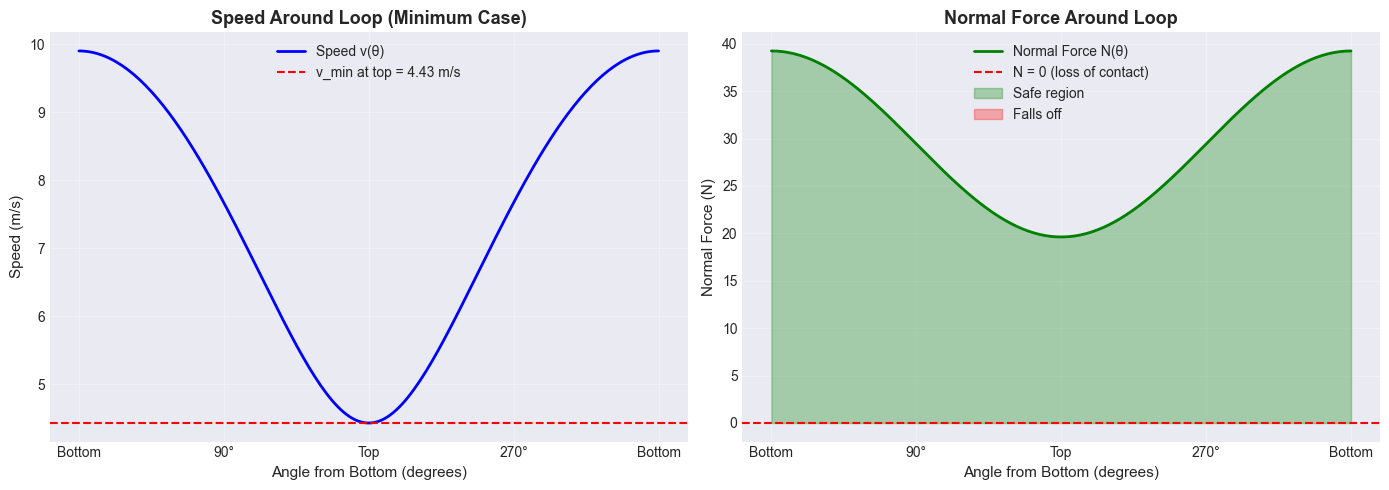

 Key observations:
 Speed is maximum at bottom (9.90 m/s), minimum at top (4.43 m/s)
 Normal force is maximum at bottom (39.24 N), minimum at top (19.62 N)
 At minimum speed, N = 0 at top (particle barely maintains contact)


In [6]:
# Visualize speed and normal force variation around loop
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Convert theta to position description
theta_degrees = np.degrees(theta)
positions = ['Bottom', '90°', 'Top', '270°', 'Bottom']
position_angles = [0, 90, 180, 270, 360]

# Plot for minimum speed case
theta1, v1, N1, _, _ = simulate_vertical_loop(R, v_min_bottom, g, m)

ax1.plot(np.degrees(theta1), v1, 'b-', linewidth=2, label='Speed v(θ)')
ax1.axhline(
    v_min_top,
    color='r',
    linestyle='--',
    label=f'v_min at top = {
        v_min_top:.2f} m/s')
ax1.set_xlabel('Angle from Bottom (degrees)', fontsize=11)
ax1.set_ylabel('Speed (m/s)', fontsize=11)
ax1.set_title(
    'Speed Around Loop (Minimum Case)',
    fontsize=13,
    fontweight='bold')
ax1.set_xticks(position_angles)
ax1.set_xticklabels(positions)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(np.degrees(theta1), N1, 'g-', linewidth=2, label='Normal Force N(θ)')
ax2.axhline(0, color='r', linestyle='--', label='N = 0 (loss of contact)')
ax2.fill_between(
    np.degrees(theta1),
    0,
    N1,
    where=(
        N1 >= 0),
    alpha=0.3,
    color='green',
    label='Safe region')
ax2.fill_between(np.degrees(theta1), N1, 0, where=(N1 < 0),
                 alpha=0.3, color='red', label='Falls off')
ax2.set_xlabel('Angle from Bottom (degrees)', fontsize=11)
ax2.set_ylabel('Normal Force (N)', fontsize=11)
ax2.set_title('Normal Force Around Loop', fontsize=13, fontweight='bold')
ax2.set_xticks(position_angles)
ax2.set_xticklabels(positions)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("Key observations:")
print(
    f" Speed is maximum at bottom ({v1[0]:.2f} m/s), minimum at top ({v1[np.argmin(np.abs(theta1-np.pi))]:.2f} m/s)")
print(
    f" Normal force is maximum at bottom ({N1[0]:.2f} N), minimum at top ({N1[np.argmin(np.abs(theta1-np.pi))]:.2f} N)")
print(f"At minimum speed, N = 0 at top (particle barely maintains contact)")


## Part 3: Multiple Interacting Particles

When we have **multiple particles** connected by springs, ropes, or rods, we must:

1. **Write Newton's law for EACH particle separately**
2. **Identify interaction forces** (action-reaction pairs)
3. **Write constraint equations** (if any)
4. **Solve the coupled system of equations**

### Example 3: Two Masses with Spring

**System**: Two masses $m_1$ and $m_2$ connected by a spring (stiffness $k$, natural length $L_0$)

**Setup**:
- Mass 1 at position $x_1$
- Mass 2 at position $x_2$
- Spring extension: $\Delta x = (x_2 - x_1) - L_0$
- Spring force: $F_{spring} = -k \cdot \Delta x$ (Hooke's Law)

**Free Body Diagrams**:

```
Mass 1: [m₁] ← F₁ = -k(x₂ - x₁ - L₀) (compressed → pushes right)
Mass 2: F₂ = k(x₂ - x₁ - L₀) → [m₂] (compressed → pushes left)
```

**Newton's 3rd Law**: $F_1 = -F_2$ (action-reaction pair)

**Newton's 2nd Law for Each Mass**:
$$m_1 \ddot{x}_1 = -k(x_2 - x_1 - L_0)$$
$$m_2 \ddot{x}_2 = k(x_2 - x_1 - L_0)$$

**This is a coupled system** - motion of $m_1$ affects $m_2$ and vice versa!

---

### Solution Methods

**Method 1: Numerical Integration** (Today)
- Treat as system of ODEs
- Use numerical solver (`scipy.integrate.solve_ivp`)
- Get $x_1(t)$ and $x_2(t)$ directly

**Method 2: Modal Analysis** (Unit 5.2 - Vibrations)
- Find natural frequencies $\omega_1, \omega_2$
- Find mode shapes
- General solution = combination of modes

**Method 3: Center of Mass + Relative Coordinates** (Advanced)
- Define $x_{cm} = \frac{m_1 x_1 + m_2 x_2}{m_1 + m_2}$ and $x_{rel} = x_2 - x_1$
- Equations decouple!

Let's simulate numerically...

![Two Masses Connected by Springs](figs/U4_L1_spring_mass.png)

*Two Masses Connected by Springs*


In [22]:
# Import ODE solver
from scipy.integrate import solve_ivp


def two_mass_spring_system(t, y, m1, m2, k, c, L0):
    """
    System of ODEs for two masses connected by horizontal spring with damping

    State vector: y = [x1, v1, x2, v2]
    Both masses slide on frictionless surface

    Forces on each mass:
    - Spring force (proportional to extension/compression)
    - Damping force (proportional to velocity)
    """
    x1, v1, x2, v2 = y

    # Spring displacement from natural length
    displacement = (x2 - x1) - L0

    # Forces on each mass
    F_spring_on_1 = k * displacement  # Spring pushes/pulls mass 1
    F_damp_1 = -c * v1
    # Spring pushes/pulls mass 2 (opposite direction)
    F_spring_on_2 = -k * displacement
    F_damp_2 = -c * v2

    # Accelerations
    a1 = (F_spring_on_1 + F_damp_1) / m1
    a2 = (F_spring_on_2 + F_damp_2) / m2

    return [v1, a1, v2, a2]


# System parameters
m1, m2 = 1.0, 2.0  # kg
k = 10.0  # N/m
c = 0.2  # N·s/m (light damping)
L0 = 1.0  # m (natural length)

# Initial conditions
x1_0, v1_0 = 0.0, 0.0  # Mass 1 at origin, at rest
x2_0, v2_0 = 0.8, 0.0  # Mass 2 compressed to 0.8m, at rest

y0 = [x1_0, v1_0, x2_0, v2_0]

# Time span
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)

# Solve ODE system
print(f"Two-Mass Spring System Simulation")
print(f"=" * 60)
print(f"Parameters:")
print(f"m₁ = {m1} kg, m₂ = {m2} kg")
print(f"Spring: k = {k} N/m, L₀ = {L0} m, c = {c} N·s/m")
print(f"\nInitial Conditions:")
print(f"Mass 1: x₁(0) = {x1_0} m, v₁(0) = {v1_0} m/s")
print(f"Mass 2: x₂(0) = {x2_0} m, v₂(0) = {v2_0} m/s")
print(
    f" Initial spring length: {
        x2_0 -
        x1_0:.2f} m (compressed from L₀ = {L0} m)")
print(f"\nSolving...")

sol = solve_ivp(two_mass_spring_system, t_span, y0, t_eval=t_eval,
                args=(m1, m2, k, c, L0), method='RK45')

x1, v1, x2, v2 = sol.y
t = sol.t

print(f"Solution complete!")
print(f"Time steps: {len(t)}")
print(f"Final positions: x₁ = {x1[-1]:.3f} m, x₂ = {x2[-1]:.3f} m")
print(f"Spring length: {x2[-1] - x1[-1]:.3f} m (natural = {L0} m)")


Two-Mass Spring System Simulation
Parameters:
 m₁ = 1.0 kg, m₂ = 2.0 kg
 Spring: k = 10.0 N/m, L₀ = 1.0 m, c = 0.2 N·s/m

Initial Conditions:
 Mass 1: x₁(0) = 0.0 m, v₁(0) = 0.0 m/s
 Mass 2: x₂(0) = 0.8 m, v₂(0) = 0.0 m/s
 Initial spring length: 0.80 m (compressed from L₀ = 1.0 m)

Solving...
 Solution complete!
 Time steps: 500
 Final positions: x₁ = -0.078 m, x₂ = 0.875 m
 Spring length: 0.954 m (natural = 1.0 m)


C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_65448\747785101.py:45: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
 plt.tight_layout()
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_65448\747785101.py:45: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
 plt.tight_layout()
C:\Users\mpstme.student\AppData\Local\Temp\ipykernel_65448\747785101.py:45: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
 plt.tight_layout()


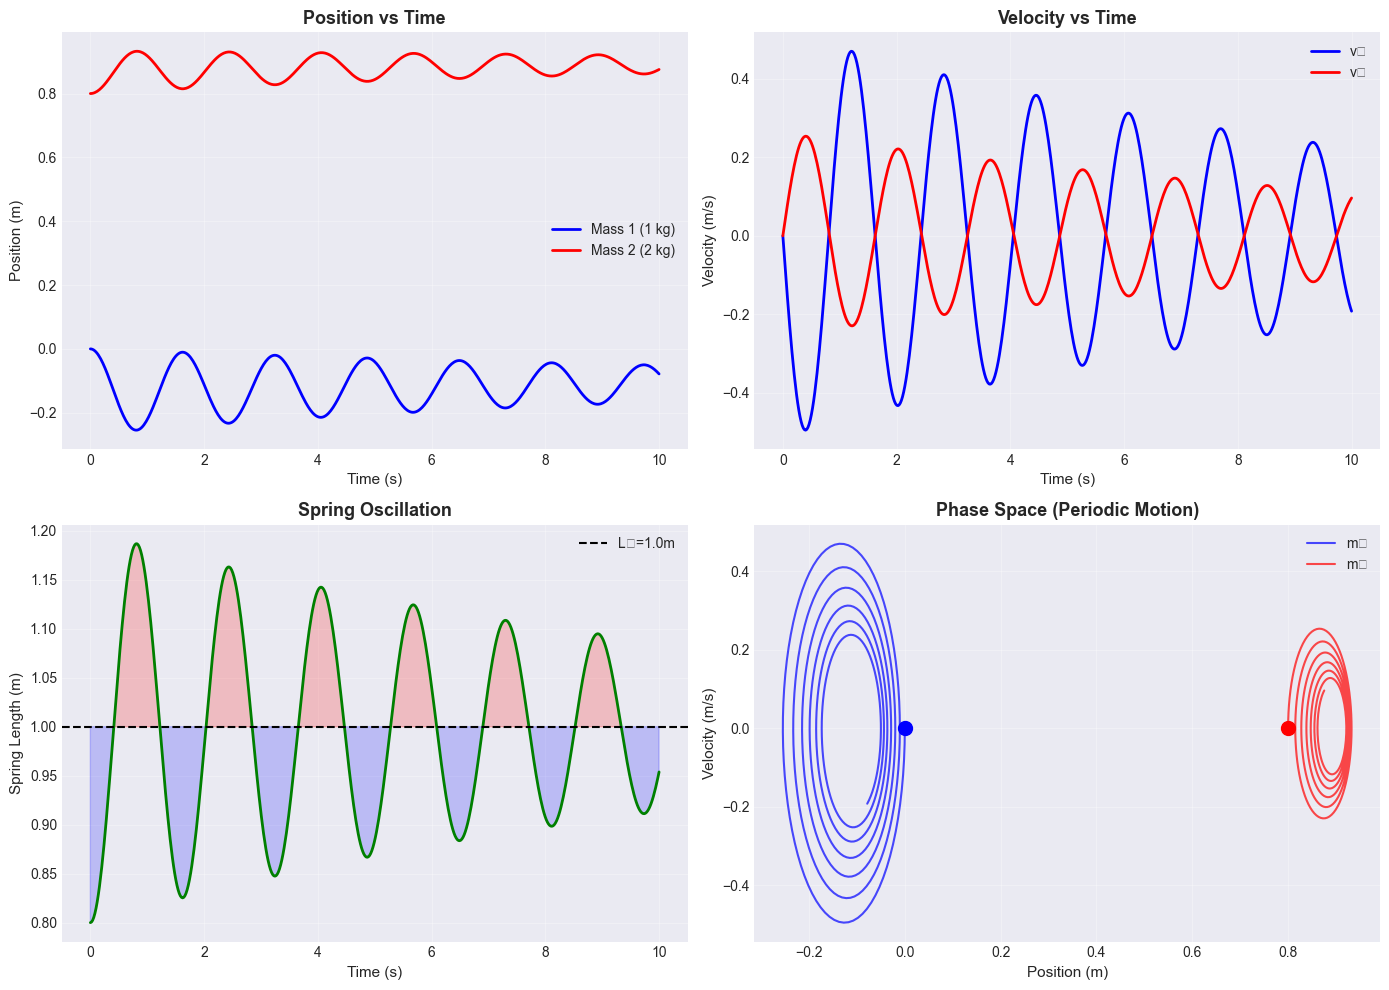

 Observations:
 Both masses oscillate periodically
 Closed orbits in phase space → periodic motion
 Spring length oscillates around natural length L₀=1.0m


In [23]:
# Visualize the two-mass spring system
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Position vs Time
axes[0, 0].plot(t, x1, 'b-', linewidth=2, label='Mass 1 (1 kg)')
axes[0, 0].plot(t, x2, 'r-', linewidth=2, label='Mass 2 (2 kg)')
axes[0, 0].set_xlabel('Time (s)', fontsize=11)
axes[0, 0].set_ylabel('Position (m)', fontsize=11)
axes[0, 0].set_title('Position vs Time', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Velocity vs Time
axes[0, 1].plot(t, v1, 'b-', linewidth=2, label='v₁')
axes[0, 1].plot(t, v2, 'r-', linewidth=2, label='v₂')
axes[0, 1].set_xlabel('Time (s)', fontsize=11)
axes[0, 1].set_ylabel('Velocity (m/s)', fontsize=11)
axes[0, 1].set_title('Velocity vs Time', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spring Length vs Time
spring_length = x2 - x1
axes[1, 0].plot(t, spring_length, 'g-', linewidth=2)
axes[1, 0].axhline(L0, color='k', linestyle='--', label=f'L₀={L0}m')
axes[1, 0].fill_between(t, L0, spring_length, where=(
    spring_length > L0), alpha=0.2, color='red')
axes[1, 0].fill_between(t, spring_length, L0, where=(
    spring_length < L0), alpha=0.2, color='blue')
axes[1, 0].set_xlabel('Time (s)', fontsize=11)
axes[1, 0].set_ylabel('Spring Length (m)', fontsize=11)
axes[1, 0].set_title('Spring Oscillation', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Phase Space
axes[1, 1].plot(x1, v1, 'b-', linewidth=1.5, alpha=0.7, label='m₁')
axes[1, 1].plot(x2, v2, 'r-', linewidth=1.5, alpha=0.7, label='m₂')
axes[1, 1].scatter([x1[0]], [v1[0]], color='blue', s=100, marker='o', zorder=5)
axes[1, 1].scatter([x2[0]], [v2[0]], color='red', s=100, marker='o', zorder=5)
axes[1, 1].set_xlabel('Position (m)', fontsize=11)
axes[1, 1].set_ylabel('Velocity (m/s)', fontsize=11)
axes[1, 1].set_title('Phase Space (Periodic Motion)',
                     fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print(f"Both masses oscillate periodically")
print(f"Closed orbits in phase space → periodic motion")
print(f"Spring length oscillates around natural length L₀={L0}m")


## Practice Problems

### Problem 1: Particle on Incline with Friction

A 2 kg block slides down a 40° incline with coefficient of friction μ = 0.3.

**Tasks**:
1. Draw the free body diagram
2. Find the acceleration down the incline
3. Find the normal force
4. How does friction affect the motion compared to frictionless case?

**Hint**: Friction force $f = \mu N$ opposes motion (points up the incline)

In [24]:
# YOUR TURN: Solve Problem 1 (Friction on Incline)
# Given
m, theta_deg, mu, g = 2.0, 40, 0.3, 9.81
theta = np.radians(theta_deg)

# Calculate:
# 1. Normal force
# 2. Friction force
# 3. Acceleration

# Your solution here:


<details>
<summary> Click to reveal solution to Problem 1</summary>

**Solution**: N = mg·cos(θ) = 15.03 N, f = μN = 4.51 N, a = g(sin θ - μ cos θ) = 4.05 m/s²

</details>

---

### Problem 2: Three-Mass System

Three equal masses (m = 1 kg each) are connected by identical springs (k = 20 N/m, L₀ = 0.5 m). 
Initial positions: x₁ = 0, x₂ = 0.7m, x₃ = 1.3m (both springs compressed by 0.2m).

**Task**: Set up the equations of motion for all three masses.

**Hint**: Each mass has forces from TWO springs (left and right neighbors).

## Summary

### Key Concepts

1. **Constraints** reduce degrees of freedom and introduce constraint forces
2. **Newton's laws** with constraints require including both applied and constraint forces
3. **Single particles**: Incline (a = g sin θ), Vertical loop (v_min = √(gR))
4. **Multiple particles**: Coupled ODEs, solved numerically, exhibit periodic motion

### Connection to Other Units
- **Unit 2 (Lagrangian)**: Eliminates constraint forces automatically
- **Unit 5 (Rigid Bodies)**: Infinite particles with constraints
- **Unit 5.2 (Vibrations)**: Modal analysis of coupled systems

---

## Homework

**HW1**: Particle on 35° incline with μ=0.25. Find acceleration and stopping distance from v₀=5 m/s.

**HW2**: Vertical loop R=8m. Find minimum speed at top, bottom, and 60° from bottom.

**HW3**: Two-mass spring (m₁=1.5kg, m₂=2.5kg, k=12 N/m). Simulate and find oscillation period.

**HW4**: Three masses in a row, connected by springs. Set up equations of motion.

**HW5**: Design roller coaster loop with safety factor 2.5. Calculate forces throughout.

---

## Next Lecture

**Unit 4, Lecture 2: Pulley Systems & Mechanical Advantage**

Topics: Atwood machine, multiple pulleys, mechanical advantage, real applications